In [33]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
%pip install numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_csv('online_retail_II.csv')

df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [38]:
df.shape[0]

1067371

In [39]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [41]:
df.dtypes

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

In [ ]:
# As we are not going to use the Description column, we can drop it
df = df.drop("Description", axis=1)

In [44]:
df.head()

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [49]:
# All duplicate rows
duplicates = df[df.duplicated(keep=False)]
duplicates.shape[0]

67246

In [50]:

# Group by all columns and count occurrences
duplicate_counts = df.groupby(df.columns.to_list()).size().reset_index(name='Count')
duplicate_counts

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,Count
0,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,1
1,489434,21523,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,1
2,489434,21871,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,1
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,1
4,489434,22064,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,1
...,...,...,...,...,...,...,...,...
797878,C581490,23144,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,1
797879,C581499,M,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,1
797880,C581568,21258,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,1
797881,C581569,20979,-5,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,1


In [52]:
# Filter out rows that appear more than once
duplicates_only = duplicate_counts[duplicate_counts['Count'] > 1]
duplicates_only

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,Count
339,489517,21491,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,2
346,489517,21821,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2
348,489517,21912,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,3
349,489517,21913,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2
352,489517,22130,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom,2
...,...,...,...,...,...,...,...,...
796255,C572226,85066,-1,2011-10-21 13:58:00,12.75,15321.0,United Kingdom,2
796556,C574095,22326,-1,2011-11-03 09:54:00,2.95,12674.0,France,2
796644,C574510,22360,-1,2011-11-04 13:25:00,2.95,15110.0,United Kingdom,2
796925,C575940,23309,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom,2


In [57]:
# Create a DataFrame with unique rows
unique_df = df.drop_duplicates()
unique_df.shape

(1033034, 7)

In [56]:
df.shape

(1067371, 7)

In [62]:
df.head()

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [67]:
non_standard_format = df[~df['Invoice'].str.match(r'^[A-Za-z0-9]+$')]
non_standard_format.shape[0]

0

<Axes: xlabel='InvoiceDate'>

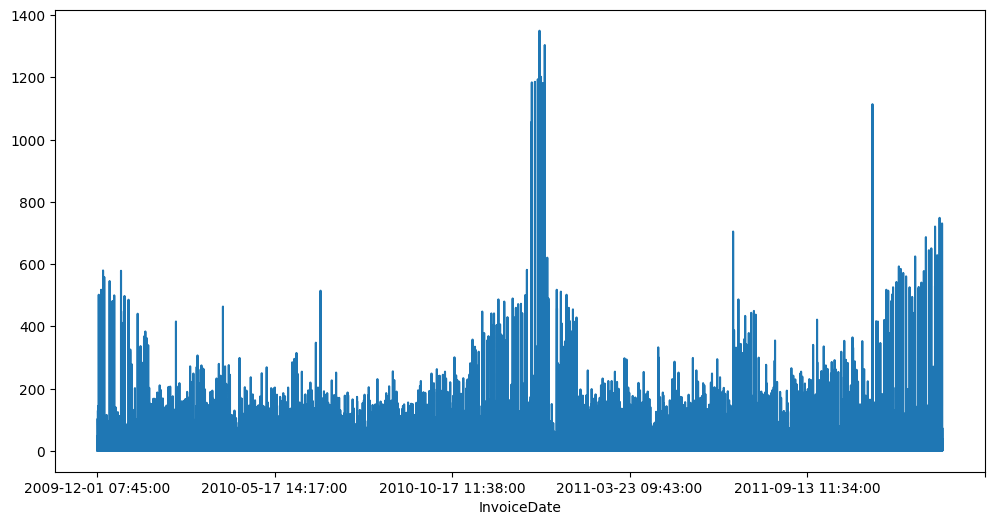

In [69]:
invoice_counts_per_day = df.groupby('InvoiceDate').size()
invoice_counts_per_day.plot(figsize=(12,6))